# Trabajo Fin de Máster  
### Análisis de la Ciudad mediante Aprendizaje Supervisado  
#### Detección Automática de Tipologías Residenciales y Patrones de Cerramiento: Interpretabilidad vs Rendimiento

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Estudio de interpretabilidad local

### 📝 Descripción del notebook

Tras la evaluación conjunta del rendimiento y la interpretabilidad realizada en el *notebook* [5_Discussion.ipynb](5_Discussion.ipynb) se ha seleccionado *XGBoost* para el despliegue en producción.

En este *notebook* se realiza un estudio de interpretabilidad local que complementa la visión global del modelo mediante el estudio de su comportamiento a nivel de instancia. Además, se presenta así la herramienta de interpretabilidad local basada en *SHAP* que se ha implementado en la plataforma interactiva (presentada en [7_App_demo.ipynb](7_App_demo.ipynb)).

### Indice de contenidos
1. [Enfoque de interpretabilidad local](#interp_local)

2. [Obtención de predicciones y valores SHAP *out-of-fold*](#out_of_fold)

3. [Análisis de observaciones individuales](#analisis)
    * [3.1 Casos de consenso](#consenso)
    * [3.2 Casos de discrepancia](#discrepancia)
    * [3.3 Casos erróneos](#errores)

# Configuración de entorno e *imports*

Este proyecto ha sido realizado en un entorno Anaconda con la versión 3.11.15 de *Python*. Las versiones de las librerias requeridas se encuentran en el fichero *requirements-full.txt*.

En esta sección se importan las librerias necesarias para la ejecución de este fichero *jupyter notebook*, se activa el *reload* de módulos externos y se configuran aspectos globales y de reproducibilidad.

In [1]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration object
from src.config import cfg

# Estimators to get out-of-fold predictions and shap values
from src.balanced_xgb import BalancedXGBClassifier
from sklearn.linear_model import LogisticRegression

# Method to plot samples in a map
from src.EDA_utils import plot_individual_sample_map

# XAI visualization methods
from src.XAI_utils import (
    # LOCAL SHAP
    get_shap_out_of_fold,
    plot_shap_waterfall,
    plot_misclassification_shap_waterfall
)

**Solución a problemas en *imports***

Si los *imports* del módulo `src` fallan al ejecutar este cuaderno en un entorno diferente, descomente y ejecute la siguiente celda:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [4]:
# Set descriptive data path to plot samples in a map
descriptive_data_path = os.path.join(cfg.DATA_PROCESSED_DIR, "descriptive_data.csv")

In [5]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

<a id="interp_local"></a>
# 1. Enfoque de interpretabilidad local

El estudio de interpretabilidad global realizado en el *notebook* [4.2_Global_interp_methodology.ipynb](4.2_Global_interp_methodology.ipynb) ha permitido identificar las variables más influyentes y caracterizar los distintos grados de cerramiento. No obstante, al tratarse de un análisis agregado, no permite explicar el comportamiento del modelo ante predicciones concretas.

Por ello, una vez seleccionado *XGBoost* como modelo final tras la discusión presentada en el *notebook* [5_Discussion.ipynb](5_Discussion.ipynb), se realiza un estudio de interpretabilidad local para analizar su comportamiento en observaciones individuales de distinta complejidad. Asimismo, este análisis introduce el mecanismo de interpretabilidad local que se integra en la plataforma interactiva desarrollada como mecanismo de transferencia de conocimiento y que se presenta en el *notebook* [7_App_demo.ipynb](7_App_demo.ipynb).


Para contextualizar el comportamiento de *XGBoost*, sus explicaciones locales se comparan con las de la regresión logística multinomial, seleccionada como modelo transparente alternativo por su rendimiento competitivo. La comparación se realiza sobre tres escenarios representativos:

* **Casos de consenso (acierto mutuo)**. Se analizan instancias correctamente clasificadas por ambos modelos para determinar si las explicaciones obtenidas muestran patrones interpretativos similares.

* **Casos de discrepancia**. Se analizan instancias en las que *XGBoost* obtiene una clasificación correcta mientras que regresión logística falla, evaluando si la mejora predictiva se debe a la captura de relaciones complejas coherentes con el conocimiento del dominio.

* **Casos erróneos**. Se examinan instancias clasificadas incorrectamente por ambos modelos para identificar los factores que dificultan la separación entre clases y limitan la capacidad predictiva.


Dado que un análisis exhaustivo de todas las observaciones resulta inviable $^1$, se han seleccionado casos ilustrativos de cada escenario con el objetivo de analizar el proceso de decisión del modelo en distintas situaciones. El análisis de estos ejemplos tiene una finalidad descriptiva, orientada a comprender el comportamiento local del modelo y complementar el estudio de interpretabilidad global. 

> $^1$ La plataforma interactiva presentada en el *notebook* [7_App_demo.ipynb](7_App_demo.ipynb) permite realizar el mismo análisis de interpretabilidad local presentado en esta sección sobre cualquier complejo residencial de la base de datos.

**Metodología**

Para realizar este análisis se emplea la técnica de interpretabilidad *post-hoc* *SHAP*, con el objetivo de disponer de un marco de interpretabilidad común que permita comparar el comportamiento de ambos modelos. Los valores *SHAP* se expresan en la escala de salida (*raw output*) de cada modelo. Dado que dicha escala difiere entre algoritmos, la comparación se centra en la dirección y el patrón de las contribuciones de las variables, y no en la magnitud absoluta de los valores *SHAP*.

El estudio de interpretabilidad local no se realiza sobre los modelos finales entrenados con el conjunto de datos completo. Si se utilizasen estos modelos las predicciones obtenidas para cada muestra no representarían un escenario de inferencia real, ya que dichas muestras habrían sido utilizadas previamente durante el entrenamiento. En consecuencia, tanto las predicciones como las explicaciones asociadas a las mismas, podrían no reflejar adecuadamente el comportamiento esperado del modelo ante datos no observados, distorsionando la validez del análisis.

Con el objetivo de aproximar el comportamiento del modelo a un entorno real de producción, se emplea una estrategia de predicción y explicabilidad *out-of-fold*. Para ello, se reutilizan las particiones externas de la *Nested Cross-Validation* y los modelos óptimos obtenidos en cada una de ellas. Para cada partición externa se realiza el siguiente procedimiento:

* El modelo se entrena, con la configuración óptima de hiperparámetros, sobre el conjunto de entrenamiento externo (*Outer Train Set*).

* Se generan las predicciones *out-of-fold* sobre las muestras del conjunto de prueba externo (*Outer Test Set*), no utilizadas durante el entrenamiento.

* Se calcula *SHAP* sobre dichas predicciones.

Tras repetir este procedimiento para todas las particiones externas, se obtienen predicciones y explicaciones *SHAP* para la totalidad del conjunto de datos, donde cada observación ha sido evaluada mediante un modelo que no ha participado en su entrenamiento. De este modo, el análisis de interpretabilidad local se aproxima a las condiciones esperadas durante el uso del modelo sobre nuevas observaciones.

La generación de predicciones y explicaciones mediante la estrategia *out-of-fold* descrita se implementa a través de la función *get_shap_out_of_fold*, ubicada en el módulo *src/XAI_utils.py*.

**Herramienta de explicabilidad local (*waterfall plot*)**

La herramienta de interpretabilidad local seleccionada para explicar predicciones individuales es el gráfico de cascada (*waterfall plot*) de la librería *shap*. Esta visualización descompone una predicción en las contribuciones aditivas de cada variable, mostrando cómo la salida del modelo evoluciona desde el valor base (*expected value*, $E[f(x)]$) hasta la predicción final ($f(x)$). Cada contribución refleja el efecto de una característica sobre la predicción, indicando tanto la dirección como la magnitud de su influencia.

Dado que se sigue una estrategia de predicción y explicabilidad *out-of-fold*, cada explicación se obtiene a partir del modelo correspondiente a la partición de la observación analizada. En consecuencia, el valor base de *SHAP* puede variar entre particiones, ya que cada modelo corresponde a un proceso independiente de optimización de hiperparámetros y entrenamiento. Para garantizar la trazabilidad del análisis, el título de cada gráfico indica el *fold* utilizado para generar la predicción y calcular los valores *SHAP*.

<a id="out_of_fold"></a>
## 2. Obtención de predicciones y valores SHAP *out-of-fold*

En esta sección se aplica la función *get_shap_out_fold* para el modelo *XGBoost* y el modelo regresión logística multinomial. Tanto las predicciones como los valores *SHAP* obtenidos para todos los complejos residenciales mediante *XGBoost* y la regresión logística multinomial se almacenan de forma estructurada en ficheros CSV ubicados en el directorio *output/SHAP_local/{model_name}*.

In [6]:
XG_model = BalancedXGBClassifier(
        random_state = SEED,
        sampling_method = "uniform",
        objective= "multi:softmax",
        eval_metric="mlogloss",
)
XG_pred_info_df, XG_probabilities_df, XG_shap_values_df, XG_expected_values_df = get_shap_out_of_fold(cfg, XG_model, "XGBoost")



             STARTING PROCESS: OUT-OF-FOLD PREDICTIONS & LOCAL SHAP             
 • Model Name      : XGBoost
 • Outer CV Folds  : 5
--------------------------------------------------------------------------------

[ FOLD 0/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__colsample_bytree  : 0.8
model__gamma             : 0.3
model__learning_rate     : 0.01
model__max_depth         : 5
model__n_estimators      : 300
model__reg_lambda        : 1
model__subsample         : 1.0

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via TreeExplainer... 

[ FOLD 1/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__colsample_bytree  : 1.0
model__gamma             : 0
model__learning_rate     : 0.01
model__max_depth         : 5
model__n_estimators      : 300
model__reg_lambda        : 1
model__s

In [7]:
LR_model = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    penalty="l2",
    random_state = SEED
)
LR_pred_info_df, LR_probabilities_df,  LR_shap_values_df, LR_expected_values_df = get_shap_out_of_fold(cfg, LR_model, "Logistic_Regression")


             STARTING PROCESS: OUT-OF-FOLD PREDICTIONS & LOCAL SHAP             
 • Model Name      : Logistic_Regression
 • Outer CV Folds  : 5
--------------------------------------------------------------------------------

[ FOLD 0/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 10

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via LinearExplainer... 

[ FOLD 1/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 10000

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via LinearExplainer... 

[ FOLD 2/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 100

Training     | Fitting model... 


<a id="analisis"></a>
# 3. Análisis de observaciones individuales

En esta sección se realiza el análisis de interpretabilidad local de observaciones particulares. Para ello se *mergean* los dataframes con las predicciones y probabilidades obtenidas con *XGBoost* y regresión logística multinomial. A partir de este dataframe pueden seleccionar instancias de los casos descritos para su posterior análisis.

In [8]:
# Load descriptive data to use LAT, LON and MUN variables to plot residential complex in the map
descriptive_data_df = pd.read_csv(descriptive_data_path)

In [9]:
# Join both predictions dataframes to compare specficic predictions
compare_pred_df = LR_pred_info_df.rename(columns={'URB_pred':'URB_LR', 'prob':'prob_LR'}).copy()
compare_pred_df = pd.merge(
    compare_pred_df,
    XG_pred_info_df[['URB_pred','prob','CC']].rename(columns={'URB_pred':'URB_XG', 'prob':'prob_XG'}),
    how="left",
    on="CC"
)

<a id="consenso"></a>
## 3.1 Casos de consenso

En esta sección se analizan observaciones clasificadas correctamente por ambos modelos con el objetivo de determinar si la mayor capacidad de modelado de *XGBoost* se traduce en explicaciones diferentes o si, en situaciones de menor complejidad, ambos modelos capturan patrones urbanísticos equivalentes.

A partir del análisis de múltiples casos de consenso se han identificado dos comportamientos diferenciados de acuerdo al grado de cerramiento. En las categorías *Protegido*, *Autoaislado* e *Individualista*, ambos modelos fundamentan sus predicciones en un conjunto de variables similar. Por el contrario, en los grados *Controlado* y *Simbólico* se identifican observaciones en las que ambos modelos alcanzan la misma clasificación a partir de patrones de decisión diferentes. A continuación, se presentan ejemplos representativos de ambas situaciones.

In [10]:
# Select succesfull cases in both models
succes_cases_df = compare_pred_df[
    (compare_pred_df["URB_LR"]==compare_pred_df["URB"]) &
    (compare_pred_df["URB_XG"]==compare_pred_df["URB"])

].copy().reset_index(drop=True)

En la siguiente figura se presenta el estudio de interpretabilidad local del complejo residencial *Autoaislado* con identificador $CC=4701004$, seleccionado como ejemplo representativo de una explicación consistente entre ambos modelos. Desde el punto de vista urbanístico, este complejo se caracteriza por su separación del núcleo urbano (*DIS_3=0*, *DIS_2=1*), la presencia de calles en fondo de saco (*CFS=1*) como elemento disuasorio y el uso y dominio público de la vía (*PPU=1*).

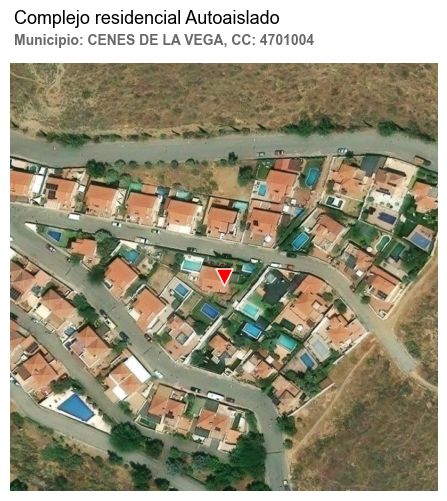

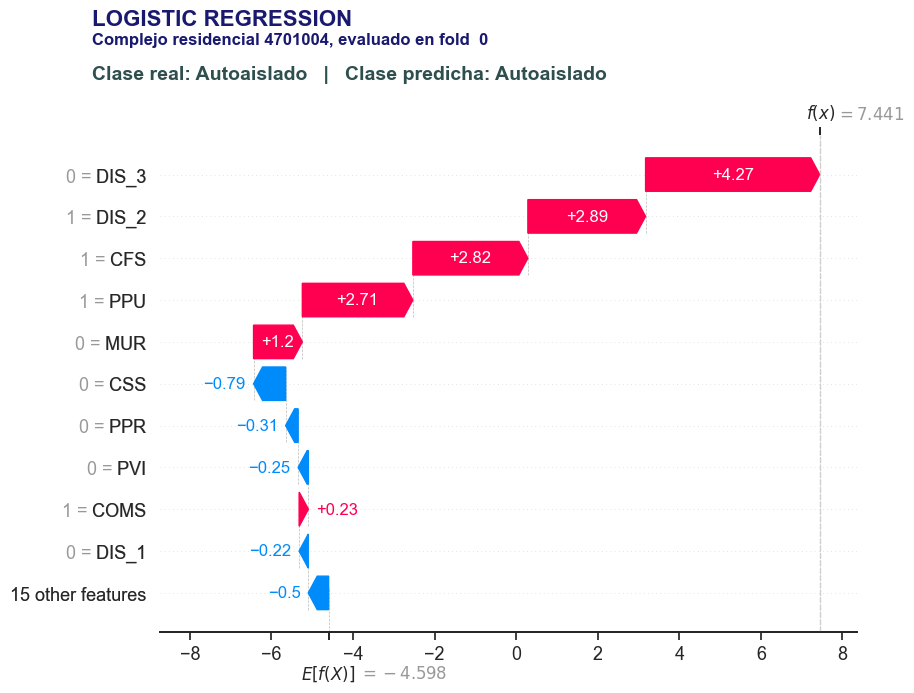

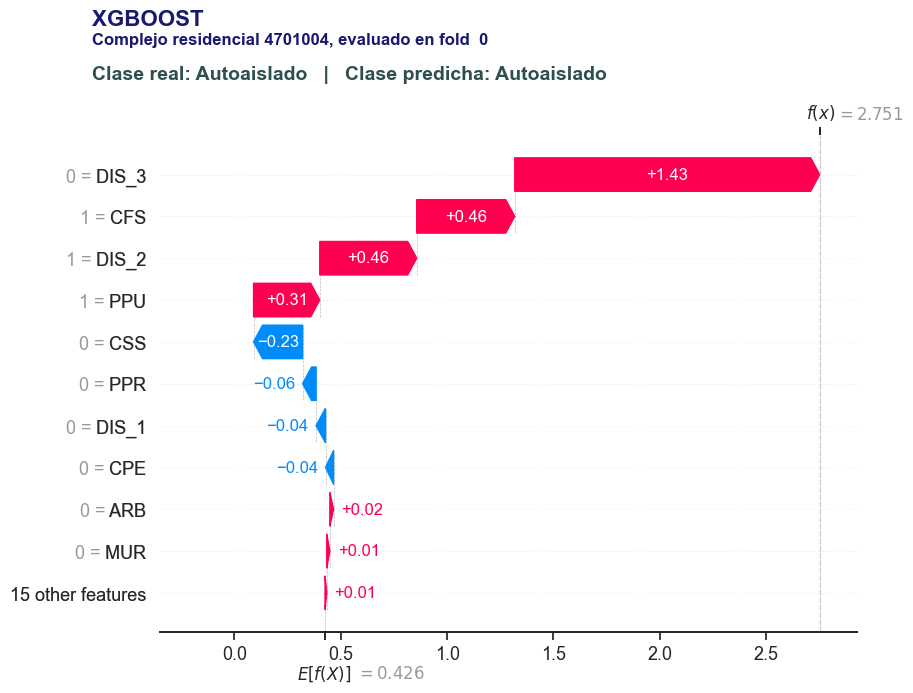

In [11]:
id_sample = 4701004
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=120)
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

Como muestran los gráficos de cascada, ambos modelos fundamentan su predicción principalmente en las variables *DIS_3*, *DIS_2*, *CFS* y *PPU*. Esta explicación local es coherente con la caracterización global del grado de cerramiento *Autoaislado*, asociado al aislamiento respecto al núcleo urbano y a la presencia de elementos viales disuasorios.

En la siguiente figura se presenta el estudio de interpretabilidad local del complejo residencial *Simbólico* con identificador $CC=8401006$, seleccionado como ejemplo representativo de una observación en la que ambos modelos coinciden en la predicción, pero sus explicaciones presentan diferencias.

Este complejo residencial se caracteriza por su integración en el núcleo urbano (*DIS_3 = 1*), el uso público de la vía (*PPU = 1*) y la ausencia de cerramientos duros (*MUR=0* y *VER=0*), en concordancia con los atributos más representativos del grado de cerramiento *Simbólico* identificados en el estudio de interpretabilidad global. No obstante, también incorpora elementos viales disuasorios, como las *calles sin salida* (*CSS = 1*) y las *calles en fondo de saco* (*CFS = 1*).

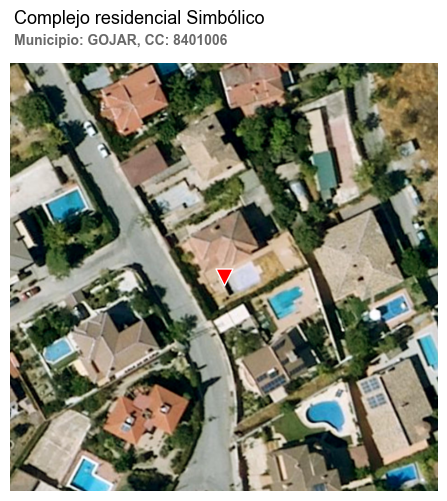

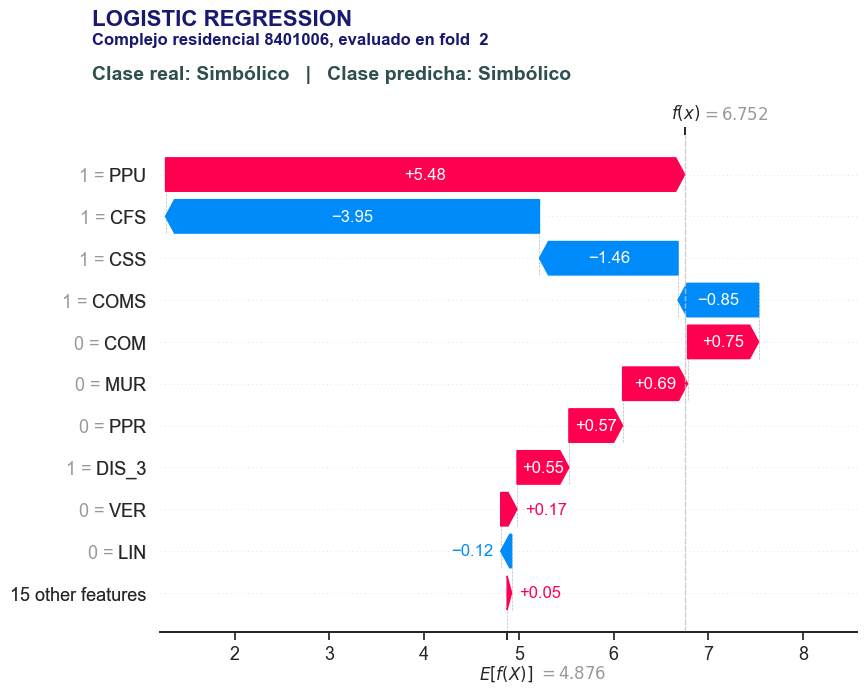

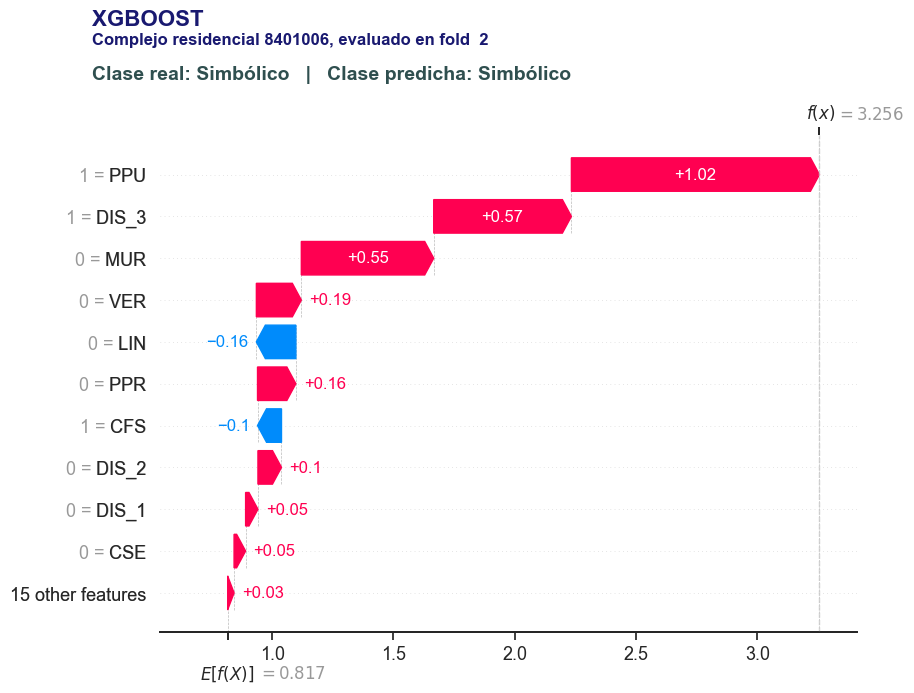

In [12]:
id_sample = 8401006
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=70)
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico de cascada muestra que la regresión logística basa su predicción principalmente en la contribución positiva del *uso público de la vía (PPU)*, mientras que las calles disuasorias (*CSS* y *CFS*) actúan como factores inhibidores. Por ello, su explicación resulta más difusa, al depender en gran medida de variables que reducen la pertenencia a la clase en lugar de aquellas que definen directamente su identidad. En cambio, *XGBoost* proporciona una interpretación más descriptiva, basada principalmente en las contribuciones positivas de *PPU*, *DIS_3*, *MUR* y *VER*. Estas variables permiten caracterizar el complejo en un grado de cerramiento sutil, asociado a su integración urbana, el uso público de la vía y la ausencia de cerramientos físicos.

Estas diferencias pueden explicarse por la naturaleza matemática de ambos algoritmos. La regresión logística multinomial establece una relación lineal mediante coeficientes globales fijos para cada combinación variable–clase. Dado que *CSS* y *CFS* presentan una fuerte asociación con la clase *Autoaislado*, sus coeficientes son elevados para dicha categoría y, por la estructura aditiva del modelo, contribuyen implícitamente a reducir la probabilidad del resto de clases cuando están presentes.

Por ello, en complejos residenciales pertenecientes a otras categorías estas variables actúan como fuertes factores inhibidores. En cambio, *XGBoost* construye la predicción mediante árboles de decisión capaces de modelar relaciones no lineales y dependencias contextuales entre variables. Por ello, características como *CSS* o *CFS* pueden tener influencia únicamente en determinadas regiones del espacio de características, reduciendo su peso cuando no aportan información discriminativa relevante. Como resultado, el gráfico de cascada de *XGBoost* proporciona una explicación más alineada con la semántica urbanística de la categoría, al basar la decisión en las variables más representativas del grado de cerramiento predicho.

Los casos de consenso analizados muestran que, en los grados de cerramiento caracterizados por variables altamente discriminativas como ocurre en los grados de cerramiento *Protegido*, *Autoaislado* e *Individualista*, ambos modelos producen explicaciones similares. Por el contrario, en categorías con patrones más difusos, como *Controlado* y *Simbólico*, aparecen diferencias entre los modelos. En estos casos, se observa que *XGBoost* tiende a proporcionar explicaciones más informativas probablemente debido a su capacidad para capturar relaciones no lineales y contextualizar el efecto de las variables.

<a id="discrepancia"></a>
## 3.2 Casos de discrepancia

En esta sección se analizan observaciones en las que *XGBoost* obtiene una clasificación correcta mientras que la regresión logística multinomial falla.

El estudio de estos casos ha mostrado que, en situaciones de mayor complejidad, donde los complejos residenciales presentan configuraciones urbanísticas híbridas que comparten características asociadas a distintos grados de cerramiento, *XGBoost* es capaz de modelar estas interacciones y obtener una clasificación correcta cuya explicación resulta coherente con el conocimiento del dominio. Para ilustrar este comportamiento se han seleccionado dos ejemplos representativos que se analizan a continuación. 

In [13]:
# Select cases where XG succes and LR fails
XG_succes_cases_df = compare_pred_df[
    (compare_pred_df["URB_LR"]!=compare_pred_df["URB"]) &
    (compare_pred_df["URB_XG"]==compare_pred_df["URB"])

].copy().reset_index(drop=True)

En la siguiente figura se presenta el estudio de interpretabilidad local del complejo residencial *Autoaislado* con $CC=2201001$.

Este caso presenta una alta complejidad para los modelos ya que combina características asociadas a dos grados de cerramiento diferentes. Por un lado, el aislamiento del núcleo urbano (*DIS_1 = 1*), las calles en fondo de saco (*CFS = 1*) y el uso público de la vía (*PPU = 1*) son elementos característicos de *Autoaislado*. Por otro lado, la presencia de cámaras (*CSE = 1*) y guardias de seguridad (*GSE = 1*) se relaciona con grados como *Protegido* y *Controlado*. Ante esta configuración híbrida, la regresión logística multinomial realiza una clasificación errónea, asignando el complejo residencial a la categoría *Protegido*.

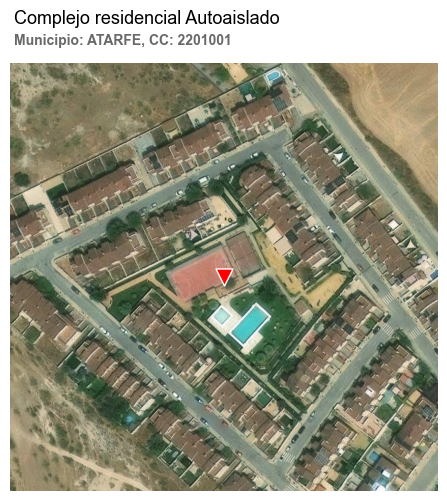

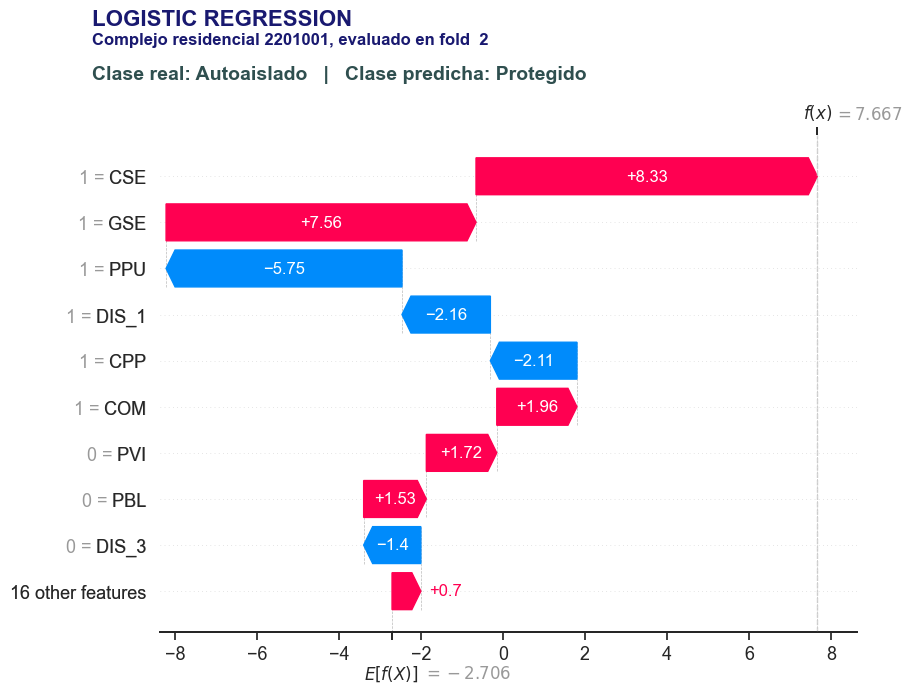

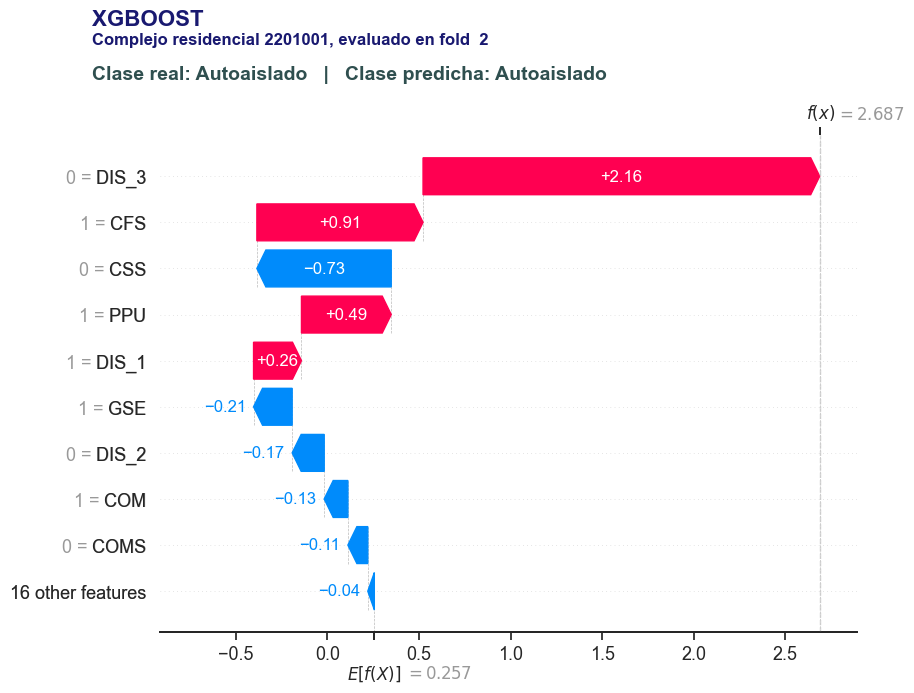

In [14]:
# Set sample ID
id_sample = 2201001
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=130)
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", num_features_display=10, figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", num_features_display=10, figsize=[9,7])

En el gráfico de cascada de la regresión logística, la presencia de *cámaras de seguridad (CSE)* y *guardias de seguridad (GSE)* aporta una fuerte contribución hacia la clase *Protegido*. Debido a la estructura lineal y aditiva del modelo, variables como el *uso público de la vía (PPU = 1)* y el aislamiento respecto al núcleo urbano (*DIS_1 = 1*) actúan como factores inhibidores, pero no compensan el peso global de las variables de seguridad.

Por el contrario, la explicación en *XGBoost*  está dominada por las variables características del grado de cerramiento *Autoaislado*, principalmente *DIS_3*, *CFS* y *PPU*. En este caso, los servicios de seguridad tienen una influencia limitada, ya que los guardias reducen ligeramente la contribución hacia esta clase y las cámaras no aparecen entre las variables más relevantes. Este comportamiento muestra que *XGBoost* es capaz de contextualizar el efecto de estas variables y reconocer que representan elementos complementarios dentro de una configuración cuyo mecanismo principal de cerramiento es el aislamiento. De este modo, el modelo no solo mejora la clasificación, sino que proporciona una explicación coherente con la interpretación urbanística.

En segundo lugar, se analiza el complejo residencial *Simbólico* con identificador $CC = 90501001$, cuyo estudio de interpretabilidad local se muestra en la siguiente figura.

Este complejo no se encuentra *integrado en el núcleo urbano (DIS_3=0)* y tampoco presenta *uso público de la vía (PPU=0)*, debido a la ausencia de viales internos. Ambas características corresponden a variables altamente influyentes en este grado de cerramiento, de acuerdo con el análisis de interpretabilidad global. La regresión logística lo clasifica erróneamente como *Autoaislado*.

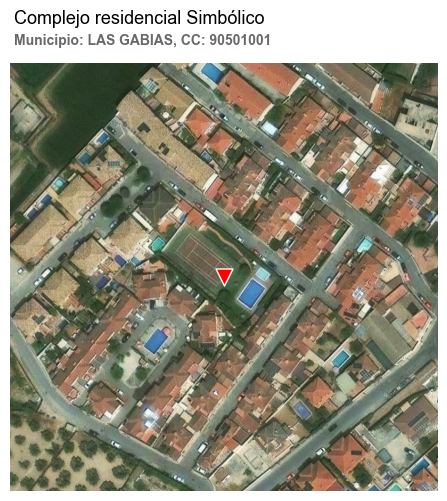

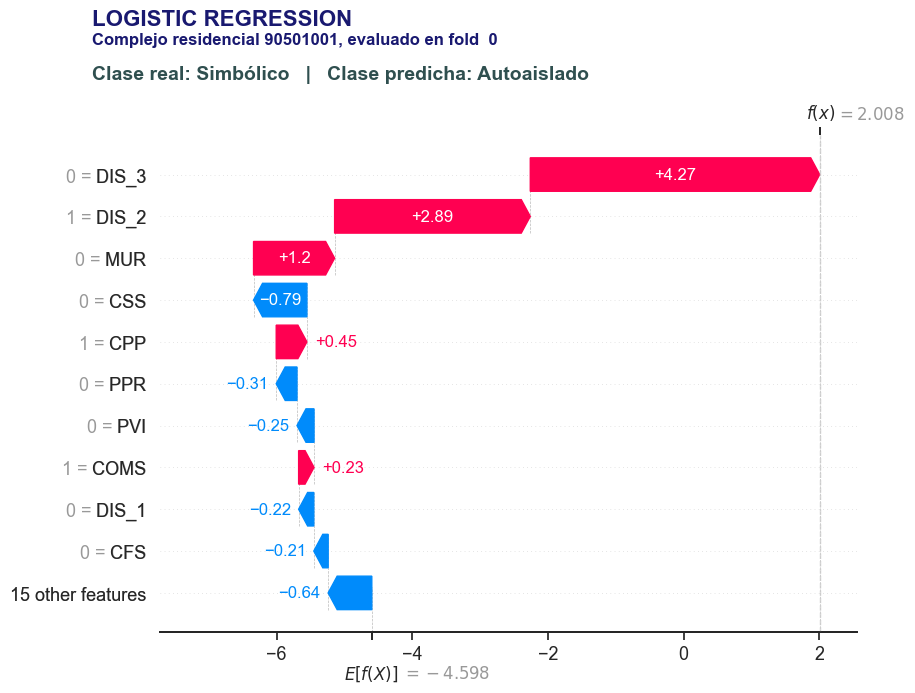

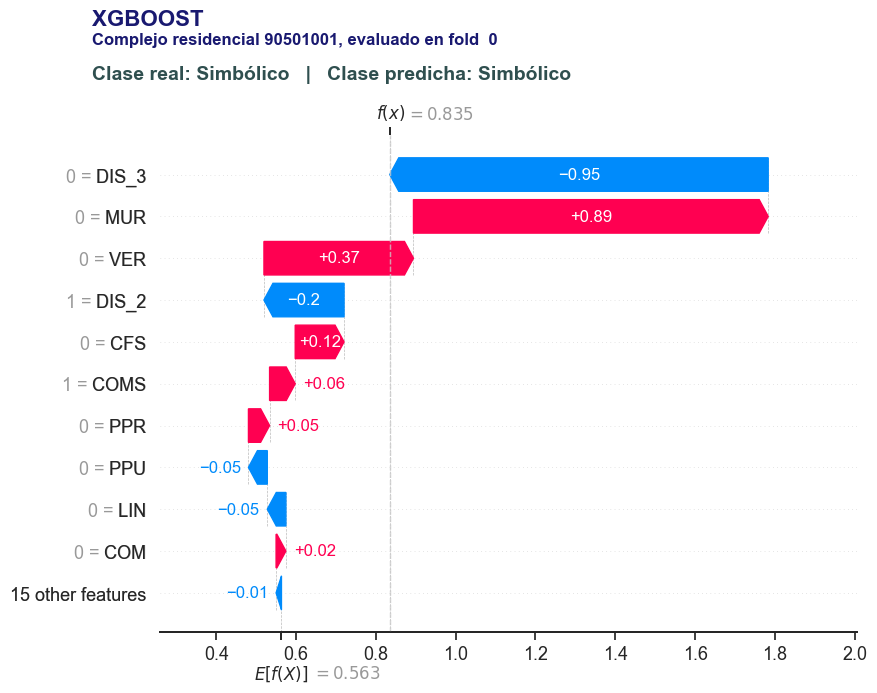

In [15]:
# Set sample ID
id_sample = 90501001
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=120)
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression",  figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

La clasificación de la regresión logística se basa principalmente en la localización del complejo residencial, como muestra el gráfico de cascada. En concreto, las variables *DIS_3* y *DIS_2* dominan la predicción, quedando la interpretabilidad reducida al aislamiento respecto al núcleo urbano.

En el caso de *XGBoost*, el gráfico de cascada muestra que la predicción se fundamenta principalmente en la ausencia de *muros (MUR = 0)* y *verjas (VER = 0)*, variables que contribuyen positivamente a la clase *Simbólico*. Este caso representa una situación de elevada complejidad, ya que el complejo presenta pocas características asociadas al grado de cerramiento *Simbólico*. No obstante, pese a su separación del núcleo urbano, no incorpora elementos característicos de *Autoaislado*, como calles disuasorias (*CSS=0*, *CFS=0*) o una configuración específica del uso de la vía (*PPU = 0*, *PPR = 0*, *PRE = 0*).

Este ejemplo muestra la capacidad de *XGBoost* para contextualizar el efecto de la no integración en el núcleo urbano, reduciendo su influencia cuando no aparece acompañada de otros atributos característicos del grado de cerramiento *Autoaislado*, como la presencia de estructura viaria interna de carácter disuasorio.

<a id="errores"></a>
## 3.3 Casos erróneos

En esta sección se analizan observaciones de mayor dificultad, en las que ambos modelos realizan una clasificación incorrecta. El estudio se centra en *XGBoost* mediante la comparación de los gráficos de cascada asociados a la clase real y a la clase predicha. Este análisis permite profundizar en el origen de los errores de clasificación, identificando las variables que favorecen la asignación a la clase incorrecta y aquellas cuya contribución resulta insuficiente para reforzar la pertenencia a la clase real.

La siguiente tabla recoge el rendimiento de los modelos desagregado por grado de cerramiento:

| Grado de cerramiento | recall(%) | Numéro de aciertos | Número de errores |
| --- | --- | --- | --- |
| **Protegido** | 91.9 | 57 | 5 |
| **Controlado** | 99.2 | 259 | 2 |
| **Autoaislado** | 97.3 | 37 | 1 |
| **Individualista** | 100.0 | 213 | 0 |
| **Simbólico** | 72.1 | 49 | 19 |

De acuerdo con estos resultados, el grado de cerramiento *Simbólico* constituye la categoría de mayor dificultad para los modelos, alcanzando *XGBoost* el mejor resultado con un *recall* del $72.1\%$. Por el contrario, el resto de categorías presentan un rendimiento notablemente superior, con tasas de acierto por encima del $92\%$. En consecuencia, el análisis de casos erróneos se centra en el grado de cerramiento *Simbólico*, con el objetivo de identificar los factores que dificultan su clasificación y limitan el rendimiento global de los modelos.

Para ello, se han seleccionado dos casos ilustrativos de las principales dificultades observadas en la clasificación de este grado de cerramiento.

In [16]:
# Select failed cases in both models
fail_cases_df = compare_pred_df[
    (compare_pred_df["URB_LR"]!=compare_pred_df["URB"]) &
    (compare_pred_df["URB_XG"]!=compare_pred_df["URB"])

].copy().reset_index(drop=True)

En primer lugar, se estudia el complejo residencial *Simbólico* con $CC=8707014$, clasificado erróneamente como *Protegido*, cuyo análisis de interpretabilidad local se muestra en la siguiente figura.

Este caso resulta especialmente relevante debido a que presenta servicios de seguridad, pero carece de características urbanísticas asociadas al grado de cerramiento *Simbólico* de acuerdo al estudio de interpretabilidad global realizado en el *notebook* [4.2_Global_interp_analysis.ipynb](4.2_Global_interp_analysis.ipynb).

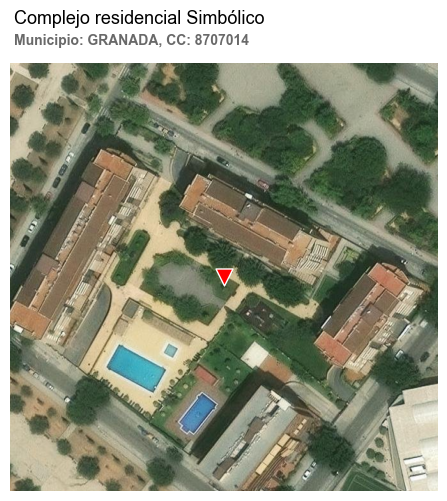

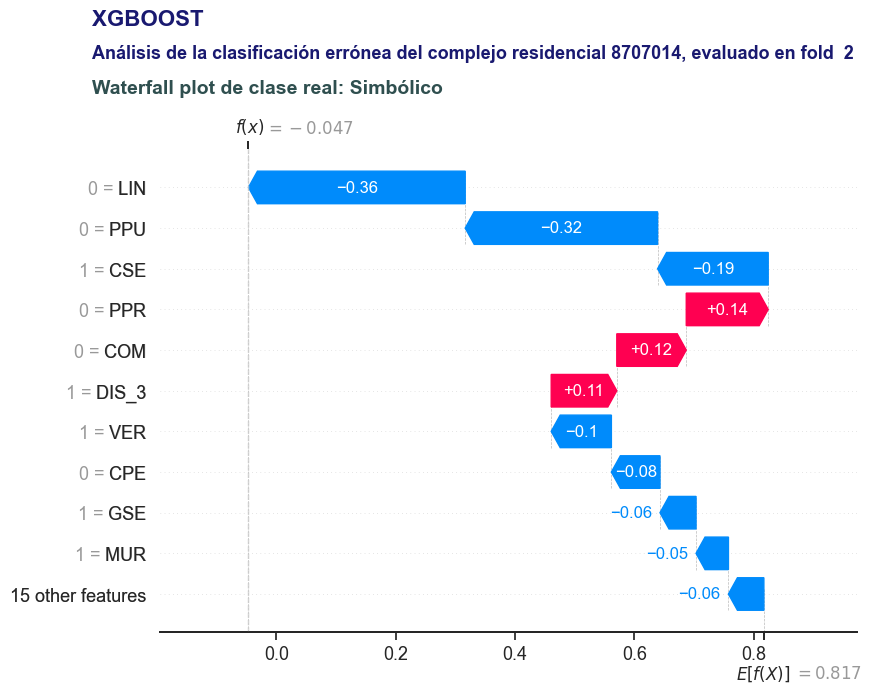

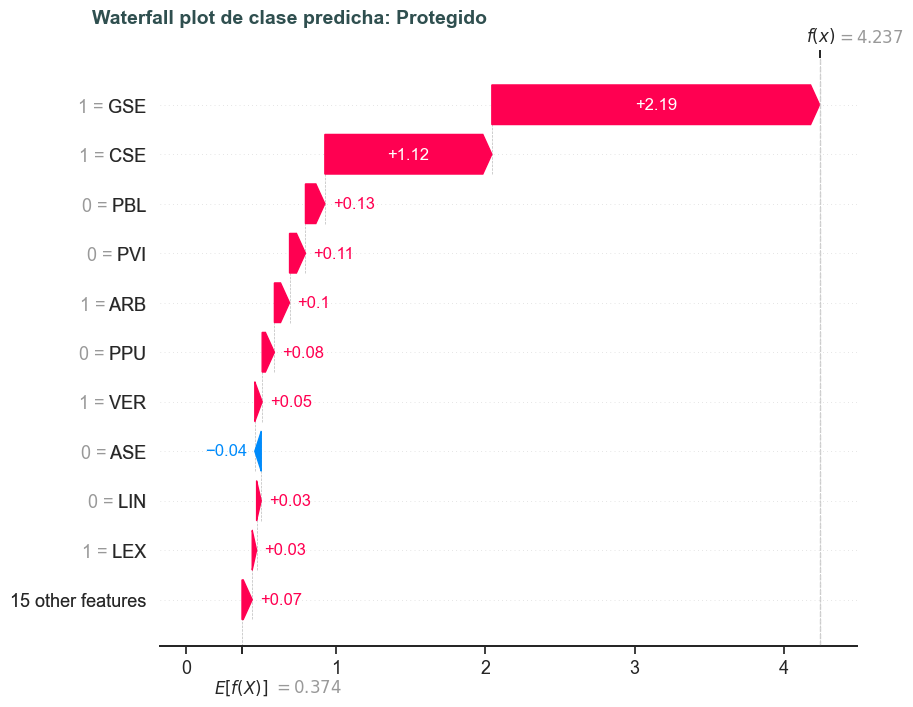

In [17]:
# Set sample ID
id_sample = 8707014
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=100)
plot_misclassification_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico de cascada del grado de cerramiento *Simbólico*  muestra una reducción significativa de la salida del modelo respecto al valor base, debido a la acumulación de contribuciones negativas asociadas tanto a la ausencia de características propias de esta categoría, como *comercios internos (LIN = 0)*, *uso público de la vía (PPU = 0)* y *calles peatonales (CPE = 0)*, como a la presencia de elementos asociados a grados de cerramiento más intensos, entre ellos *cámaras de seguridad (CSE = 1)*, *guardia de seguridad (GSE = 1)*, *muros (MUR = 1)* y *verjas (VER = 1)*.

Por el contrario, el gráfico de cascada de la clase predicha muestra que la presencia de los servicios de seguridad (*CSE = 1*, *GSE = 1*) constituye el principal factor que impulsa la salida del modelo hacia el grado de cerramiento *Protegido*.

De acuerdo con la configuración urbanística de este complejo residencial, la predicción de la categoría *Protegido* resulta coherente con el conocimiento del dominio. Este caso pone de manifiesto la dificultad de representar determinadas configuraciones residenciales pertenecientes al grado de cerramiento *Simbólico* a partir de las variables disponibles en el conjunto de datos. Ante la ausencia de contribuciones suficientemente discriminativas hacia esta categoría, el modelo sitúa la observación en una región del espacio de características más próxima a *Protegido*, debido principalmente a la presencia de servicios de seguridad.

En segundo lugar se analiza el complejo residencial *Simbólico*, con $CC=14501029$, clasificado erróneamente como *Individualista*, cuyo estudio de interpretabilidad local se muestra en la siguiente figura.

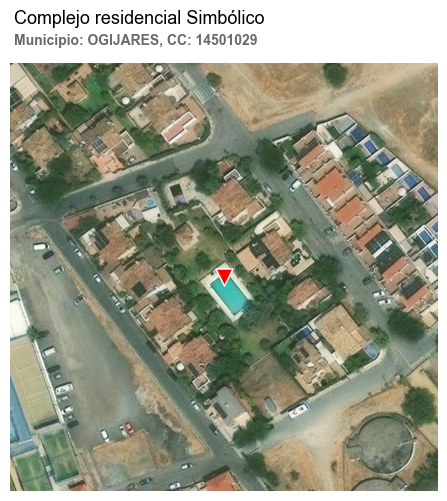

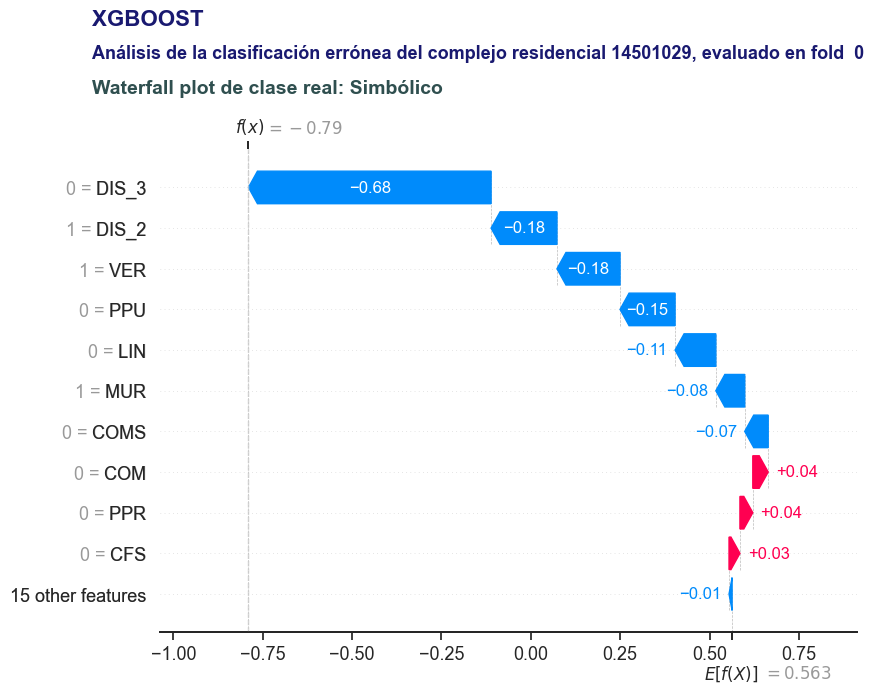

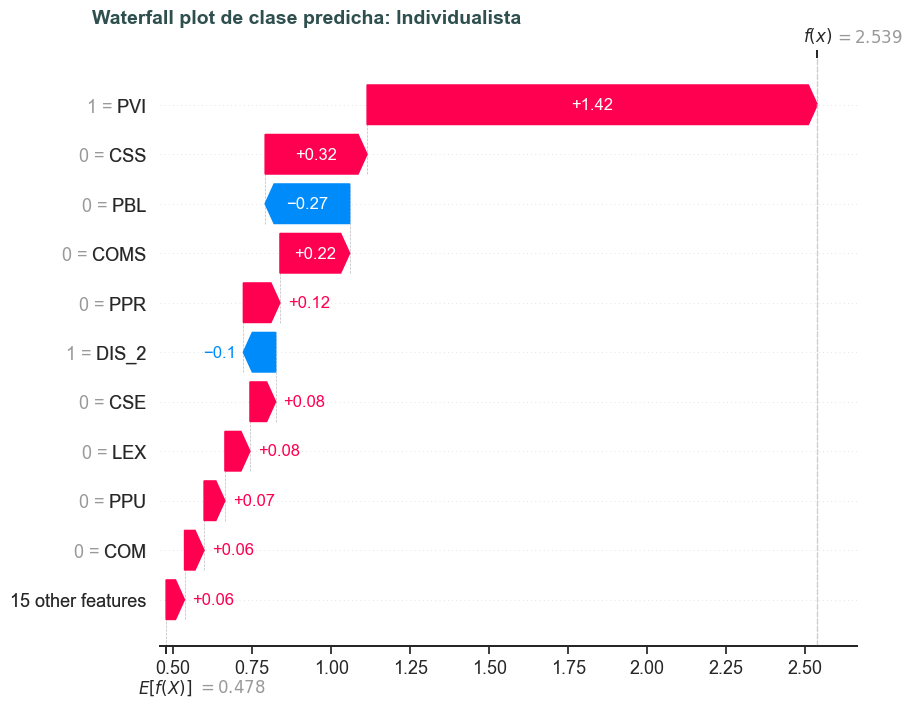

In [18]:
# Set sample ID
id_sample = 14501029
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=100)
plot_misclassification_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico de cascada de la clase *Simbólico* muestra una acumulación de contribuciones negativas, reflejando la ausencia de características asociadas a esta categoría. En concreto, el complejo no presenta ninguno de sus principales factores catalizadores y su configuración urbanística se caracteriza por el aislamiento respecto al núcleo urbano (*DIS_2=1*), la presencia de cerramientos físicos de tipo duro (*MUR=1*, *VER=1*), la ausencia de uso público de la vía (*PPU=0*) y la ausencia de comercios internos (*LIN=0*).

Por el contrario, la predicción hacia *Individualista* está dominada por la presencia de acceso por vivienda (*PVI=1*), que constituye el principal factor catalizador de esta clasificación.

Los ejemplos analizados en esta sección muestran que la principal limitación del modelo en la clasificación del grado de cerramiento *Simbólico* es la dificultad para representar adecuadamente la diversidad de configuraciones asociadas a esta categoría mediante las variables disponibles.

De acuerdo a la caracterización obtenida en el análisis de interpretabilidad global, el modelo identifica este grado de cerramiento a partir de cuatro dimensiones principales:
- Integración en el núcleo urbano. 
- Ausencia de cerramientos físicos de tipo duro. 
- Uso público de la vía. 
- Presencia de comercios internos.

Los resultados de rendimiento indican que únicamente el $\approx 72\%$ de los complejos residenciales etiquetados como *Simbólico* pueden ser identificados a través de este patrón urbanístico, mientras que el $28\%$ restante corresponde a configuraciones que no quedan suficientemente descritas por estas variables. 

El análisis local de estos casos evidencia que, ante la ausencia de características asociadas a *Simbólico*, el modelo identifica patrones alternativos más próximos a otros grados de cerramiento. Cuando la configuración urbanística presenta una alineación clara con otra categoría, la predicción está respaldada por una interpretación coherente con el conocimiento del dominio. Sin embargo, en otros casos la clasificación responde a una similitud residual, asignando la observación a la clase más próxima en el espacio de características, sin una interpretación urbanística sólida.

Las variables predictoras que describen la morfología urbana de este conjunto de datos presentan algún tipo de relación con la intensidad del cerramiento. Sin embargo, la categoría *Simbólico* representa un nivel de cerramiento sutil o incluso inexistente, por lo que dichas variables pueden no ser suficientes para caracterizar de forma clara la ausencia de cerramiento.

Aunque los *comercios internos* y la ausencia de cerramientos físicos de tipo duro constituyen los atributos más representativos de este grado de cerramiento, al presentar una asociación específica con *Simbólico*, su baja frecuencia de aparición en el conjunto de datos limita su capacidad para caracterizar de forma general esta categoría. Del mismo modo, los cerramientos de tipo blando (bolardos, arbustos, carteles de propiedad privada y cadenas) que podrían aportar información relevante desde una perspectiva urbanística, tienen una frecuencia de aparición igualmente limitada y muestran una baja asociación con este grado de cerramiento, tal y como se ha identificado en el [análisis exploratorio](1_EDA.ipynb).

En consecuencia, una línea de mejora para futuras campañas de recopilación de datos puede consistir en incorporar variables urbanísticas orientadas específicamente a capturar configuraciones de baja intensidad de cerramiento, incluyendo elementos que permitan representar de forma más completa las estrategias sutiles de delimitación espacial. Esta ampliación de la representación del fenómeno permitiría mejorar la separabilidad entre categorías y reforzar la capacidad del modelo para identificar complejos residenciales pertenecientes al grado de cerramiento *Simbólico*.